Let's practice linear regression with advertising dataset

In [69]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
# Loop progress
from tqdm import tqdm

In [60]:
df = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/refs/heads/master/data/advertising.csv')

Let's take a look at the dataset and get some basic statistics

In [52]:
display(df)
display(df.describe())
display(df.info())

,tv,radio,journaux,ventes
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


,tv,radio,journaux,ventes
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tv        200 non-null    float64
 1   radio     200 non-null    float64
 2   journaux  200 non-null    float64
 3   ventes    200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


None

Target is ventes.

Predictors are tv, radio, journaux

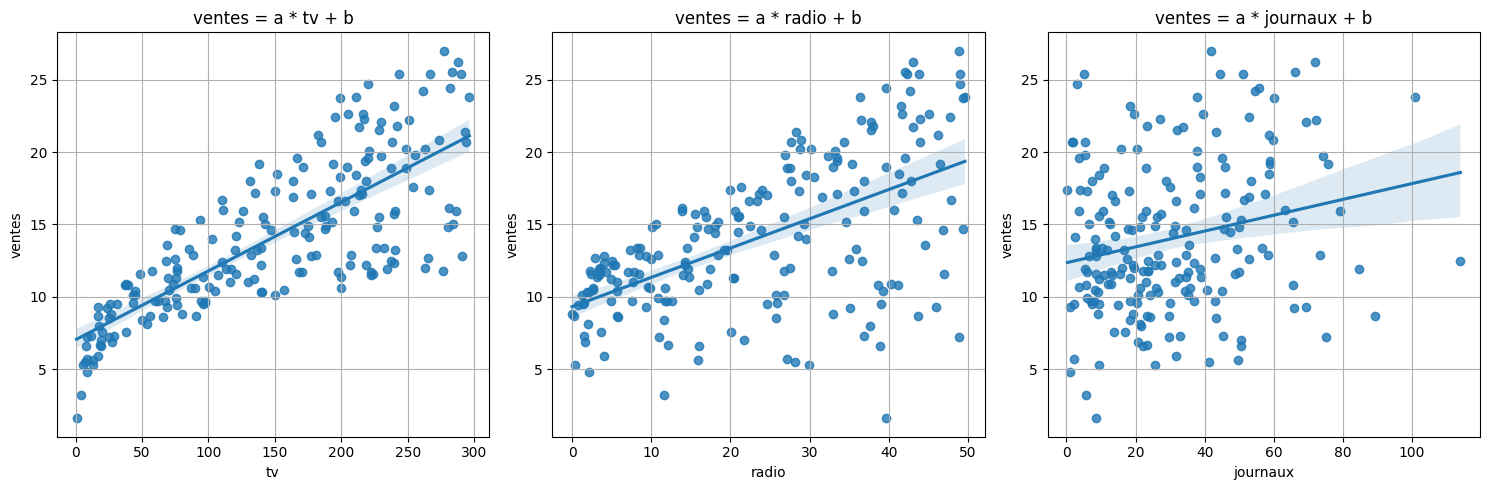

In [53]:
#3 graphs of scatter plots with the regression line
fig, axes = plt.subplots(1,3, figsize=(15, 5))

xs = ['tv', 'radio', 'journaux']

for ax, x in zip(axes, xs):
    sns.regplot(data=df, x=x, y='ventes', ax=ax)
    ax.set_title(f'ventes = a * {x} + b')
    ax.grid(True)

plt.tight_layout()
plt.show()

light blue is the uncertainty of the model. The bigger the less trustworthy is the model.

Based on the graphs: 
- TV is more predictive of the price than 
- the radio which is more than newspaper

Let's verrify it with correlation coefficients

In [54]:
df.corr()[['ventes']]

,ventes
tv,0.782224
radio,0.576223
journaux,0.228299
ventes,1.000000


Confirmed.

Now, let's choose the linear regression model from scikit-learn

# Linear regression

In [ ]:
reg = LinearRegression()
X = df[['tv', 'radio', 'journaux']] 
y = df['ventes']

#split to test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

#train the model
reg.fit(X_train, y_train)

#predict
y_pred_test = reg.predict(X_test)

#check the performance
print(f"RMSE: {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test):.2f}")
print(f"R²: {r2_score(y_test, y_pred_test):.2f}")

RMSE: 3.17
MAPE: 0.15
R²: 0.90


MAPE is close to 0, and R² is close to 1,

Hence the score seems pretty good.

But we probably can improve it. Let's try.

# 1st improvement.

Ventes vs TV seems squared rather than linear (it curves down next to y axis on the graph).

So let's consider it in our calculations

Since we add a power of one of the variables in the regession, it's **polynomial regression**.

TV raised to the second power is going to be way bigger than the other, linear, values.

Therefore we'll normalise the squared TV.

In [62]:
#raising tv to the 2nd power

df['tv2'] = df.tv**2
variables = ['tv','radio','journaux','tv2']

#normalise the amplitude with MinMaxScaler that
#forces values between 0 and 1

#create the scaler
scaler = MinMaxScaler()

#fit the scaler to the data (fit it between 0 and 1)
#scaler.fit(df)

#transform the data
#data_array = scaler.transform(df)

#fit and transform in one step
data_array = scaler.fit_transform(df[variables])

df_scaled = pd.DataFrame(data_array, columns=variables)   

#let's check that it's done
df_scaled.describe().loc[['min', 'max']]

,tv,radio,journaux,tv2
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [63]:
#retrain the normalised model with the new feature
X = df_scaled[variables] 
y = df.ventes

#split to test and train sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

#train the model
reg.fit(X_train, y_train)

#predict
y_hat_test = reg.predict(X_test)

#check the performance
print(f"Coefficients: {reg.coef_}")
print(f"RMSE: {mean_squared_error(y_test, y_hat_test):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_test):.2f}")
print(f"R²: {r2_score(y_test, y_hat_test):.2f}")

Coefficients: [22.35381258  9.51593019  0.55820668 -9.2908828 ]
RMSE: 2.38
MAPE: 0.13
R²: 0.92


Therefore it performs a bit better.

# New regressions

Sur le même principe, on va comparer les 3 régressions


- `ventes ~ tv + radio + journaux`
- `ventes ~ tv + radio + journaux + tv^2`
- `ventes ~ tv + radio + journaux + tv * radio`

In [67]:
#new variable tv * radio
df['tv_radio'] = df.tv * df.radio

#new regressions:
regressions = {
    'simple: y ~ tv + radio + journaux'  :     ['tv','radio','journaux'],
    'quadratique: y ~ tv + radio + journaux + tv2': ['tv','radio','journaux', 'tv2'],
    'terme croisée: y ~ tv + radio + journaux + tv*radio':['tv','radio','journaux', 'tv_radio']
}

#target it the same
y = df.ventes

#loop through new regressions
for title, variables in regressions.items():
    # il faut limiter l'amplitude sur toutes les variables predictrices
    scaler = MinMaxScaler()
    data_array = scaler.fit_transform(df[variables])
    # df_scaled = pd.DataFrame(data_array, columns = variables)
    
    # X = df_scaled[variables]
    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(data_array, y, test_size=0.20, random_state=42)

    # entrainer le modele
    reg.fit(X_train, y_train)
    # Prediction sur le test set
    y_pred_test = reg.predict(X_test)

    # Scores
    print(f"\n-- Regression {title}")
    print(f"\tRMSE: {mean_squared_error(y_test, y_pred_test):.2f}")
    print(f"\tMAPE: {mean_absolute_percentage_error(y_test, y_pred_test):.2f}")
    print(f"\tR²: {r2_score(y_test, y_pred_test):.2f}")



-- Regression simple: y ~ tv + radio + journaux
	RMSE: 3.17
	MAPE: 0.15
	R²: 0.90

-- Regression quadratique: y ~ tv + radio + journaux + tv2
	RMSE: 2.38
	MAPE: 0.13
	R²: 0.92

-- Regression terme croisée: y ~ tv + radio + journaux + tv*radio
	RMSE: 0.81
	MAPE: 0.07
	R²: 0.97


3rd model is the best!

# Random seed influence

In [70]:
train_test_ratio = [0.2, 0.4, 0.6, 0.8]

random_seeds = [n for n  in  range(0,200,1)]

# back to simple regression
X = df[['tv','radio','journaux']]
y = df.ventes

scores = []

for ratio in tqdm(train_test_ratio):       
    for seed in random_seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=seed)
        
        reg.fit(X_train, y_train)
        # Prediction sur le test set
        y_pred_test = reg.predict(X_test)

        scores.append({
            'ratio': ratio,
            'seed': seed, 
            'rmse': mean_squared_error(y_test, y_pred_test)
        })
scores = pd.DataFrame(scores)

100%|██████████| 4/4 [00:01<00:00,  3.66it/s]


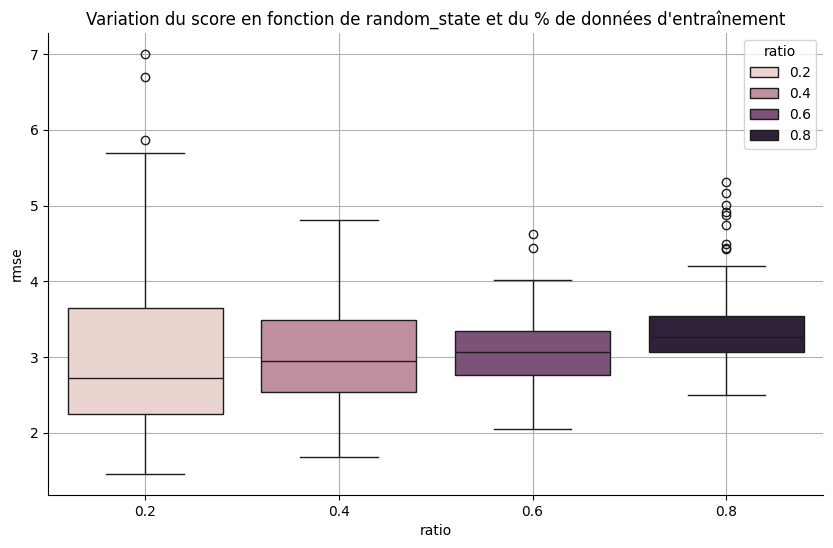

In [71]:
fig = plt.figure(figsize=(10, 6))
sns.boxplot(x = 'ratio', y = 'rmse', hue = 'ratio', data = scores )
sns.despine()
plt.title("Variation du score en fonction de random_state et du % de données d'entraînement")
plt.grid()